In [1]:
# SETUP
import numpy as np

GLOBAL_SEED = 1557
np.random.seed(GLOBAL_SEED)

from qiskit import ClassicalRegister
from qiskit.quantum_info import Pauli
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler

from src.p1.ghz_circuit import dynamic_ghz_circuit, unitary_ghz_circuit

from qiskit_aer.noise import NoiseModel, ReadoutError, depolarizing_error, pauli_error

## Problem 1. GHZ State

<img src="figures/ghz_circuit.png" alt="GHZ Circuit" width="500">

### 1.1 Unitary GHZ State Preparation

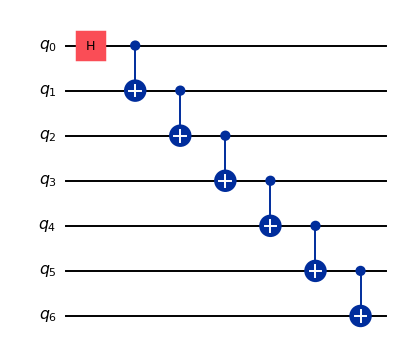

In [2]:
from qiskit import QuantumCircuit

n = 7
unitary_ghz = QuantumCircuit(n, name="Unitary GHZ")

unitary_ghz.h(0)
for qubit in range(n - 1):
    unitary_ghz.cx(qubit, qubit + 1)

unitary_ghz.draw("mpl", scale=0.7)

### 1.2 GHZ State Preparation Using Dynamic Circuit

(i) Pushing every second CNOT gate to the very right introduces the extra pink CNOT gates.

(ii) We can omit CNOT gates that are conditioned on state $|0\rangle$.

(iii) As every second qubit is only involved at the very end, we can use those before and reset them.

(iv) A Bell state followed by a CNOT gate results in two uncorrelated qubits in states $|+\rangle$ and $|0\rangle$.

(v) We move the pink CNOT gates along the Bell states to the respective qubits above (they commute with the other CNOTs
they are “passing”).

(vi) Pushing the pink CNOT gates to the left through the purple CNOT gates introduces the extra orange CNOT gates.

(vii) We make use of the principle of deferred measurement.

(viii) In a final step we merge the classically-conditioned gates. As the classical calculation can be done extremely fast compared to quantum gates, we draw it as a vertical line. The orange $\oplus$ correspond to XOR gates, i.e. addition mod 2. We also represented the initial Bell states again with their circuit representation.

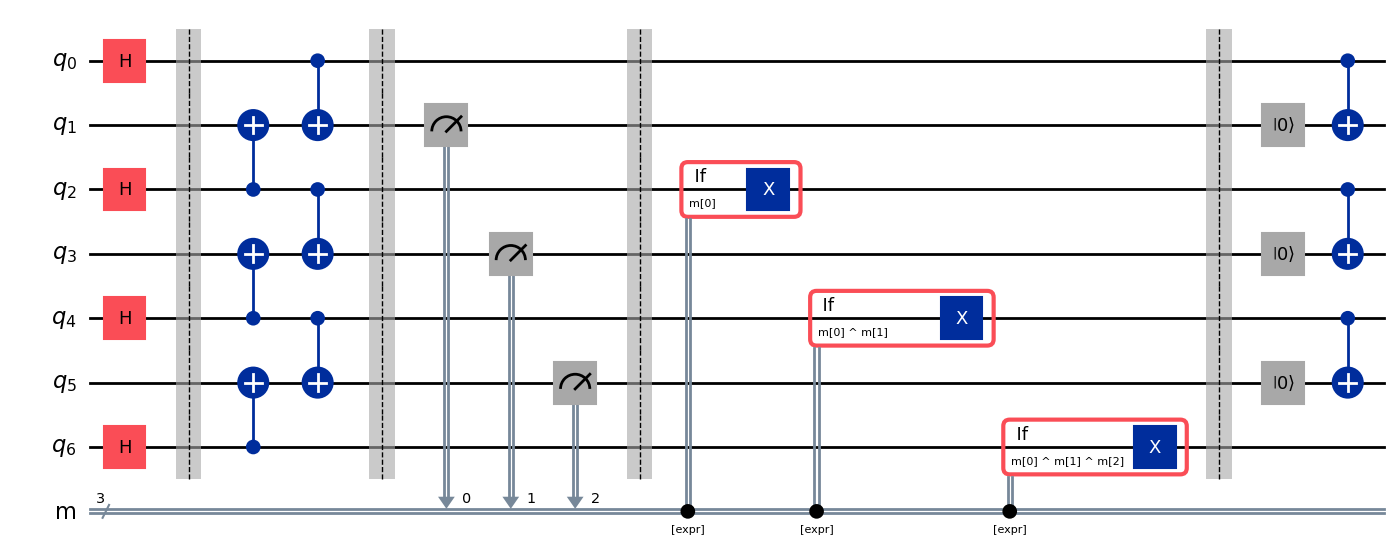

In [3]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit.classical import expr

q = QuantumRegister(7, "q")
m = ClassicalRegister(3, "m")
dynamic_ghz = QuantumCircuit(q, m, name="Dynamic GHZ")

dynamic_ghz.h([q[0], q[2], q[4], q[6]])
dynamic_ghz.barrier()

for right, ancilla in [(2, 1), (4, 3), (6, 5)]:
    dynamic_ghz.cx(q[right], q[ancilla])
for left, ancilla in [(0, 1), (2, 3), (4, 5)]:
    dynamic_ghz.cx(q[left], q[ancilla])
dynamic_ghz.barrier()


for bit, ancilla in enumerate([1, 3, 5]):
    dynamic_ghz.measure(q[ancilla], m[bit])
dynamic_ghz.barrier()


parity = expr.lift(m[0])
for bit, target in enumerate([2, 4, 6]):
    if bit > 0:
        parity = expr.bit_xor(parity, m[bit])
    with dynamic_ghz.if_test(parity):
        dynamic_ghz.x(q[target])
dynamic_ghz.barrier()


for ancilla in [1, 3, 5]:
    dynamic_ghz.reset(q[ancilla])

for control, target in [(0, 1), (2, 3), (4, 5)]:
    dynamic_ghz.cx(q[control], q[target])

dynamic_ghz.draw("mpl", fold=-1)

### Functions of Resources

####  — Unitary —

Two-qubit gate depth: $n-1=O(n)$

Number of CNOTs: $n-1$

Idle time: $O(n^2)$

Number of mid-circuit measurements: 0

#### — Dynmic Circuit —

Two-qubit gate depth: $O(1)$

Number of CNOTs: $\frac{3n}{2} - 1$

Idle time: $O(n)$

Number of mid-circuit measurements: $\frac{n}{2} -1$

<img src="figures/resource_plot.png" alt="Resource plot" width="900">

#### Equivalence of the unitary and dynamic GHZ circuits for $n=3$

Since the statevector dimension grows exponentially, we explicitly compare the two circuits for $n=3$. We use Qiskit's basis ordering

$$
\{|q_2q_1q_0\rangle\}=\{|000\rangle,|001\rangle,\ldots,|111\rangle\}.
$$

##### Unitary circuit

The initial state is

$$
|\psi_0\rangle=|000\rangle
=\begin{bmatrix}1&0&0&0&0&0&0&0\end{bmatrix}^{\mathsf T}.
$$

After $H_0$,

$$
|\psi_1^{(U)}\rangle
=\frac{|000\rangle+|001\rangle}{\sqrt2}
=\frac1{\sqrt2}\begin{bmatrix}1&1&0&0&0&0&0&0\end{bmatrix}^{\mathsf T}.
$$

After $\mathrm{CX}_{0\rightarrow1}$,

$$
|\psi_2^{(U)}\rangle
=\frac{|000\rangle+|011\rangle}{\sqrt2}
=\frac1{\sqrt2}\begin{bmatrix}1&0&0&1&0&0&0&0\end{bmatrix}^{\mathsf T}.
$$

After $\mathrm{CX}_{1\rightarrow2}$,

$$
|\psi_{\mathrm{final}}^{(U)}\rangle
=\frac{|000\rangle+|111\rangle}{\sqrt2}
=\frac1{\sqrt2}\begin{bmatrix}1&0&0&0&0&0&0&1\end{bmatrix}^{\mathsf T}.
$$

##### Dynamic circuit

After $H_0H_2=H\otimes I\otimes H$,

$$
|\psi_1^{(D)}\rangle
=\frac{|000\rangle+|001\rangle+|100\rangle+|101\rangle}{2}
=\frac12\begin{bmatrix}1&1&0&0&1&1&0&0\end{bmatrix}^{\mathsf T}.
$$

After $\mathrm{CX}_{2\rightarrow1}$,

$$
|\psi_2^{(D)}\rangle
=\frac{|000\rangle+|001\rangle+|110\rangle+|111\rangle}{2}
=\frac12\begin{bmatrix}1&1&0&0&0&0&1&1\end{bmatrix}^{\mathsf T}.
$$

After $\mathrm{CX}_{0\rightarrow1}$,

$$
|\psi_3^{(D)}\rangle
=\frac{|000\rangle+|011\rangle+|101\rangle+|110\rangle}{2}
=\frac12\begin{bmatrix}1&0&0&1&0&1&1&0\end{bmatrix}^{\mathsf T}.
$$

Measuring $q_1$ gives $m=q_0\oplus q_2$. Each outcome occurs with probability $1/2$:

$$
|\psi_{m=0}\rangle
=\frac{|000\rangle+|101\rangle}{\sqrt2}
=\frac1{\sqrt2}\begin{bmatrix}1&0&0&0&0&1&0&0\end{bmatrix}^{\mathsf T},
$$

$$
|\psi_{m=1}\rangle
=\frac{|011\rangle+|110\rangle}{\sqrt2}
=\frac1{\sqrt2}\begin{bmatrix}0&0&0&1&0&0&1&0\end{bmatrix}^{\mathsf T}.
$$

For $m=1$, the feed-forward correction $X_2$ gives

$$
X_2|\psi_{m=1}\rangle
=\frac{|010\rangle+|111\rangle}{\sqrt2}
=\frac1{\sqrt2}\begin{bmatrix}0&0&1&0&0&0&0&1\end{bmatrix}^{\mathsf T}.
$$

Resetting $q_1$ maps both measurement branches to the same state:

$$
|\psi_4^{(D)}\rangle
=\frac{|000\rangle+|101\rangle}{\sqrt2}
=\frac1{\sqrt2}\begin{bmatrix}1&0&0&0&0&1&0&0\end{bmatrix}^{\mathsf T}.
$$

Finally, $\mathrm{CX}_{0\rightarrow1}$ re-entangles the reset qubit:

$$
|\psi_{\mathrm{final}}^{(D)}\rangle
=\frac{|000\rangle+|111\rangle}{\sqrt2}
=\frac1{\sqrt2}\begin{bmatrix}1&0&0&0&0&0&0&1\end{bmatrix}^{\mathsf T}
=|\psi_{\mathrm{final}}^{(U)}\rangle.
$$

Thus, after measurement, feed-forward, reset, and re-entanglement, the dynamic circuit prepares exactly the same GHZ state as the unitary circuit.

## Fidelity

### GHZ stabilizers

A stabilizer $S$ has following property:

$$
S|\psi\rangle=|\psi\rangle.
$$

For the $n$-qubit GHZ state

$$
|\mathrm{GHZ}_n\rangle
=\frac{|0\rangle^{\otimes n}+|1\rangle^{\otimes n}}{\sqrt2},
$$

a convenient set of $n$ independent stabilizer generators for GHZ state is

$$
g_0=X_0X_1\cdots X_{n-1},\qquad
g_i=Z_{i-1}Z_i\quad(i=1,\ldots,n-1).
$$

The operator $g_0=X^{\otimes n}$ exchanges $|0\rangle^{\otimes n}$ and $|1\rangle^{\otimes n}$, so their equal superposition is unchanged: $g_0|GHZ_n\rangle=|GHZ_n\rangle$. 

Each $g_i=Z_{i-1}Z_i$ checks whether two neighboring qubits have equal computational-basis values. Both components of the GHZ state pass every such parity check with eigenvalue $+1$.

All products of these generators also stabilize the GHZ state. The resulting stabilizer group $\mathcal S_{\mathrm{GHZ}}$ contains $2^n$ operators, including the identity. 

Some products carry a minus sign; for example, $XXX\cdot ZZI=-YYX$ for $n=3$. The sign is part of the stabilizer and must be retained when measuring its expectation value.

### Fidelity from stabilizer expectation values

Let $\rho$ denote the noisy state prepared by either the unitary or the dynamic circuit. The GHZ-state fidelity is

$$
F_{\mathrm{GHZ}}=\langle \mathrm{GHZ}_n|\rho|\mathrm{GHZ}_n\rangle.
$$

The ideal GHZ projector is the uniform average of all GHZ stabilizers:

$$
|\mathrm{GHZ}_n\rangle\langle\mathrm{GHZ}_n|
=\frac{1}{2^n}\sum_{S\in\mathcal S_{\mathrm{GHZ}}}S,
$$

the exact fidelity is

$$
F_{\mathrm{GHZ}}
=\frac{1}{2^n}\sum_{S\in\mathcal S_{\mathrm{GHZ}}}\langle S\rangle_\rho.
$$

Measuring every stabilizer becomes expensive as $n$ increases. Instead, we uniformly sample $M$ stabilizers $S_1,\ldots,S_M$ and use the Monte Carlo estimator

$$
\widetilde F_{\mathrm{GHZ}}
=\frac{1}{M}\sum_{k=1}^{M}\langle S_k\rangle_\rho.
$$

This is an unbiased estimator of the exact fidelity, with stabilizer-sampling uncertainty scaling as $O(M^{-1/2})$.

### Measuring a sampled stabilizer

For each Pauli operator in a sampled stabilizer, rotate the measurement basis before the final computational-basis measurement:

- $Z$: measure directly.
- $X$: apply $H$, then measure.
- $Y$: apply $S^\dagger$ followed by $H$, then measure.
- $I$: ignore that qubit when calculating the parity.

For a measurement result $b$, the single-shot eigenvalue is

$$
s(b)=\operatorname{sign}(S)(-1)^{\sum_{j:P_j\neq I}b_j}.
$$

Averaging this value over $N_{\mathrm{shots}}$ shots estimates the stabilizer expectation value:

$$
\langle S\rangle_\rho
\approx\frac{1}{N_{\mathrm{shots}}}
\sum_{b}s(b).
$$

The complete procedure is therefore: randomly sample $M$ GHZ stabilizers, construct and execute one measurement circuit for each sampled stabilizer, estimate every $\langle S_k\rangle$, and average the results. The same sampled stabilizers and shot count should be used for the unitary and dynamic circuits to make the comparison fair.

A measured fidelity satisfying

$$
\widetilde F_{\mathrm{GHZ}}>\frac12
$$

certifies genuine multipartite entanglement. For the dynamic circuit, the mid-circuit measurement bits and the final stabilizer-measurement bits should be stored in separate classical registers.

#### Verifying the Circuit On Noiseless Simulator

We first verify that the circuits give fidelity of 1 on noiseless simulator

We will use $n=7$ for the simulations.

The preparation circuits are imported from `src.p1.ghz_circuit`. We sample the same stabilizers for both implementations so that the comparison is fair.

In [4]:
def ghz_stabilizer_generators(n):
    """Return the n independent generators of the n-qubit GHZ state."""
    generators = [Pauli("X" * n)]
    for qubit in range(n - 1):
        label = ["I"] * n  # Qiskit label order: q_(n-1) ... q_0
        label[n - 1 - qubit] = "Z"
        label[n - 2 - qubit] = "Z"
        generators.append(Pauli("".join(label)))
    return generators


def sample_ghz_stabilizers(n, num_stabilizers, seed=GLOBAL_SEED):
    """Uniformly sample distinct signed GHZ stabilizers."""
    if not 1 <= num_stabilizers <= 2**n:
        raise ValueError("num_stabilizers must be between 1 and 2**n")

    rng = np.random.default_rng(seed)
    masks = rng.choice(2**n, size=num_stabilizers, replace=False)
    generators = ghz_stabilizer_generators(n)
    stabilizers = []

    for mask in masks:
        stabilizer = Pauli("I" * n)
        for index, generator in enumerate(generators):
            if (mask >> index) & 1:
                stabilizer = stabilizer.compose(generator)

        signed_label = stabilizer.to_label()
        sign = -1 if signed_label.startswith("-") else 1
        pauli_label = signed_label.lstrip("+-")
        if pauli_label.startswith("i"):
            raise ValueError("A GHZ stabilizer must have a real phase")
        stabilizers.append((sign, pauli_label))

    return stabilizers


def append_stabilizer_measurement(preparation_circuit, pauli_label):
    """Copy a preparation circuit and append the required Pauli measurement."""
    circuit = preparation_circuit.copy()
    stabilizer_bits = ClassicalRegister(circuit.num_qubits, "stabilizer")
    circuit.add_register(stabilizer_bits)

    # pauli_label and measured bit strings both use q_(n-1) ... q_0 order.
    for qubit, pauli in enumerate(reversed(pauli_label)):
        if pauli == "X":
            circuit.h(qubit)
        elif pauli == "Y":
            circuit.sdg(qubit)
            circuit.h(qubit)

    circuit.measure(range(circuit.num_qubits), stabilizer_bits)
    return circuit


def stabilizer_expectation(counts, sign, pauli_label):
    """Estimate one signed Pauli expectation value from shot counts."""
    weighted_sum = 0
    total_shots = sum(counts.values())

    for bitstring, frequency in counts.items():
        parity = sum(
            int(bit)
            for bit, pauli in zip(bitstring, pauli_label)
            if pauli != "I"
        ) % 2
        weighted_sum += sign * ((-1) ** parity) * frequency

    return weighted_sum / total_shots


def monte_carlo_ghz_fidelity(
    preparation_circuit,
    sampled_stabilizers,
    backend,
    shots=2048,
):
    """Estimate GHZ fidelity by averaging sampled stabilizer expectations."""
    measurement_circuits = [
        append_stabilizer_measurement(preparation_circuit, pauli_label)
        for _, pauli_label in sampled_stabilizers
    ]

    pass_manager = generate_preset_pass_manager(
        backend=backend,
        optimization_level=0,
        seed_transpiler=GLOBAL_SEED,
    )
    isa_circuits = pass_manager.run(measurement_circuits)
    result = Sampler(mode=backend).run(isa_circuits, shots=shots).result()

    expectations = []
    for pub_result, (sign, pauli_label) in zip(result, sampled_stabilizers):
        counts = pub_result.data.stabilizer.get_counts()
        expectations.append(stabilizer_expectation(counts, sign, pauli_label))

    return float(np.mean(expectations)), np.asarray(expectations)


# Noiseless n=7 comparison
n = 7
num_stabilizers = 32
shots = 2048

unitary_n7 = unitary_ghz_circuit(n, do_measure=False)
dynamic_n7 = dynamic_ghz_circuit(n, do_measure=False, add_barriers=False)
sampled_stabilizers = sample_ghz_stabilizers(
    n, num_stabilizers, seed=GLOBAL_SEED
)

noiseless_simulator = AerSimulator()
noiseless_simulator.set_options(seed_simulator=GLOBAL_SEED)

fidelity_unitary, expectations_unitary = monte_carlo_ghz_fidelity(
    unitary_n7,
    sampled_stabilizers,
    noiseless_simulator,
    shots=shots,
)
fidelity_dynamic, expectations_dynamic = monte_carlo_ghz_fidelity(
    dynamic_n7,
    sampled_stabilizers,
    noiseless_simulator,
    shots=shots,
)

print(f"Unitary GHZ fidelity (n={n}): {fidelity_unitary:.6f}")
print(f"Dynamic GHZ fidelity (n={n}): {fidelity_dynamic:.6f}")

Unitary GHZ fidelity (n=7): 1.000000
Dynamic GHZ fidelity (n=7): 1.000000


#### Calculating the Fidelity on Noisy Simulator

We now calculate the fidelity on noisy simulator.

We sweeped over `[4, 6, 8, 10, 12, 14, 16, 18, 20]` qubits.

The custom Aer noise model applies depolarizing errors to one- and two-qubit gates, a reset error, and a symmetric readout error. 

Because both implementations use the same noise parameters and stabilizer samples, their estimated fidelities can be compared directly.

QEM method like twirling and M3 measurement mitigation is used.


In [5]:
def make_ghz_noise_model(
    one_qubit_error=0.001,
    two_qubit_error=0.01,
    reset_error=0.01,
    readout_error=0.02,
):
    """Create a simple, reproducible noise model for the GHZ comparison."""
    noise_model = NoiseModel()

    error_1q = depolarizing_error(one_qubit_error, 1)
    error_2q = depolarizing_error(two_qubit_error, 2)
    error_reset = pauli_error(
        [("X", reset_error), ("I", 1 - reset_error)]
    )
    error_readout = ReadoutError(
        [
            [1 - readout_error, readout_error],
            [readout_error, 1 - readout_error],
        ]
    )

    noise_model.add_all_qubit_quantum_error(
        error_1q,
        ["h", "x", "y", "z", "sdg"],
    )
    noise_model.add_all_qubit_quantum_error(error_2q, ["cx"])
    noise_model.add_all_qubit_quantum_error(error_reset, ["reset"])
    noise_model.add_all_qubit_readout_error(error_readout)
    return noise_model

  n   Unitary raw    Unitary + M3   Dynamic raw    Dynamic + M3
---------------------------------------------------------------------
  4  0.8618 +/- 0.0182  0.9689 +/- 0.0047  0.8304 +/- 0.0219  0.9331 +/- 0.0115
  6  0.7841 +/- 0.0209  0.9377 +/- 0.0065  0.7194 +/- 0.0242  0.8618 +/- 0.0146
  8  0.6995 +/- 0.0227  0.8623 +/- 0.0157  0.6165 +/- 0.0200  0.7686 +/- 0.0127
 10  0.7358 +/- 0.0254  0.8741 +/- 0.0311  0.6382 +/- 0.0296  0.7589 +/- 0.0324
 12  0.6211 +/- 0.0280  0.7216 +/- 0.0558  0.5081 +/- 0.0275  0.5922 +/- 0.0499
 14  0.5554 +/- 0.0313  0.6370 +/- 0.0600  0.4461 +/- 0.0294  0.5119 +/- 0.0523
 16  0.5426 +/- 0.0411  0.6444 +/- 0.0679  0.4242 +/- 0.0464  0.5040 +/- 0.0654
 18  0.4681 +/- 0.0314  0.5919 +/- 0.0658  0.3396 +/- 0.0267  0.4319 +/- 0.0510
 20  0.4249 +/- 0.0316  0.5593 +/- 0.0691  0.2960 +/- 0.0220  0.3922 +/- 0.0489


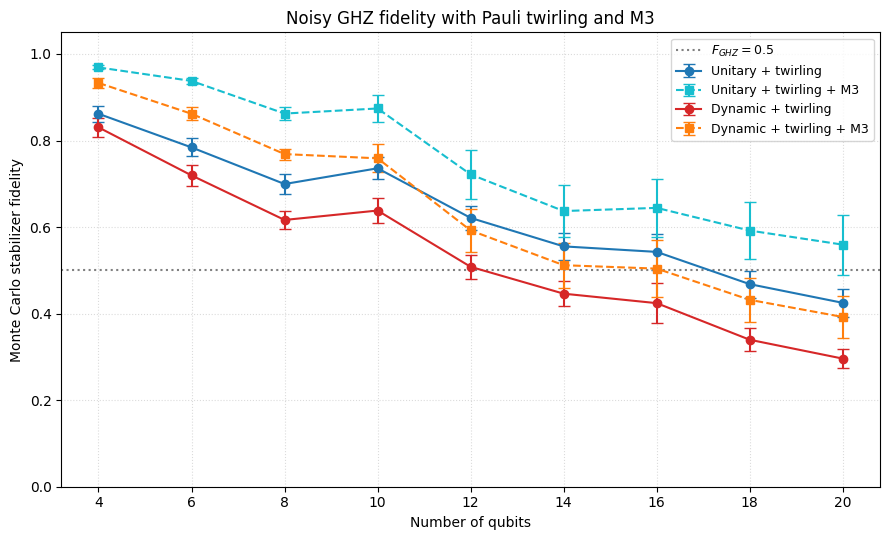

In [ ]:
# -------------------------4-10 qubit sweep: twirling + M3-------------------------
import matplotlib.pyplot as plt
import mthree

from qiskit import QuantumCircuit

sweep_qubits = [4, 6, 8, 10, 12, 14, 16, 18, 20]
sweep_num_stabilizers = 12
sweep_num_twirls = 4
sweep_shots = 1024
sweep_seed = GLOBAL_SEED

_pauli_bits = {
    "I": (0, 0),
    "X": (1, 0),
    "Y": (1, 1),
    "Z": (0, 1),
}
_bits_pauli = {bits: pauli for pauli, bits in _pauli_bits.items()}


def _apply_pauli(circuit, pauli, qubit):
    if pauli == "X":
        circuit.x(qubit)
    elif pauli == "Y":
        circuit.y(qubit)
    elif pauli == "Z":
        circuit.z(qubit)


def pauli_twirl_cx(circuit, rng):
    """Replace each CX by an equivalent randomly Pauli-twirled CX."""
    twirled = QuantumCircuit(*circuit.qregs, *circuit.cregs, name=circuit.name)
    twirled.global_phase = circuit.global_phase
    twirled.metadata = dict(circuit.metadata or {})
    paulis = np.array(["I", "X", "Y", "Z"])

    for instruction in circuit.data:
        if instruction.operation.name != "cx":
            twirled.append(
                instruction.operation,
                instruction.qubits,
                instruction.clbits,
            )
            continue

        control, target = instruction.qubits
        pre_control, pre_target = rng.choice(paulis, size=2)
        xc, zc = _pauli_bits[pre_control]
        xt, zt = _pauli_bits[pre_target]

        # CNOT conjugation: Xc -> XcXt and Zt -> ZcZt.
        post_control = _bits_pauli[(xc, zc ^ zt)]
        post_target = _bits_pauli[(xt ^ xc, zt)]

        _apply_pauli(twirled, pre_control, control)
        _apply_pauli(twirled, pre_target, target)
        twirled.cx(control, target)
        _apply_pauli(twirled, post_control, control)
        _apply_pauli(twirled, post_target, target)

    return twirled


def make_twirled_stabilizer_circuits(preparation, stabilizers, num_twirls, seed):
    """Create circuits in stabilizer-major, twirl-minor order."""
    rng = np.random.default_rng(seed)
    circuits = []
    for _, pauli_label in stabilizers:
        for _ in range(num_twirls):
            twirled_preparation = pauli_twirl_cx(preparation, rng)
            circuits.append(
                append_stabilizer_measurement(twirled_preparation, pauli_label)
            )
    return circuits


def expectation_from_distribution(distribution, sign, pauli_label):
    """Calculate a Pauli expectation from counts or M3 quasiprobabilities."""
    weighted_sum = 0.0
    total_weight = float(sum(distribution.values()))

    for outcome, weight in distribution.items():
        if isinstance(outcome, int):
            bitstring = format(outcome, f"0{len(pauli_label)}b")
        else:
            bitstring = outcome.replace(" ", "")

        parity = sum(
            int(bit)
            for bit, pauli in zip(bitstring, pauli_label)
            if pauli != "I"
        ) % 2
        weighted_sum += sign * ((-1) ** parity) * weight

    return weighted_sum / total_weight


def analyze_twirled_result(result, stabilizers, num_twirls, n_qubits, mitigator):
    """Return raw and M3 fidelities with Monte Carlo standard errors."""
    raw_expectations = []
    m3_expectations = []
    pub_index = 0

    for sign, pauli_label in stabilizers:
        raw_per_twirl = []
        m3_per_twirl = []

        for _ in range(num_twirls):
            counts = result[pub_index].data.stabilizer.get_counts()
            pub_index += 1
            raw_per_twirl.append(
                expectation_from_distribution(counts, sign, pauli_label)
            )

            quasi = mitigator.apply_correction(counts, list(range(n_qubits)))
            m3_per_twirl.append(
                expectation_from_distribution(quasi, sign, pauli_label)
            )

        raw_expectations.append(float(np.mean(raw_per_twirl)))
        m3_expectations.append(float(np.mean(m3_per_twirl)))

    raw_expectations = np.asarray(raw_expectations)
    m3_expectations = np.asarray(m3_expectations)
    denominator = np.sqrt(len(stabilizers))

    return {
        "raw": float(np.mean(raw_expectations)),
        "raw_sem": float(np.std(raw_expectations, ddof=1) / denominator),
        "m3": float(np.mean(m3_expectations)),
        "m3_sem": float(np.std(m3_expectations, ddof=1) / denominator),
    }


sweep_noise_model = make_ghz_noise_model()
sweep_simulator = AerSimulator(
    method="stabilizer",
    noise_model=sweep_noise_model,
)
sweep_simulator.set_options(seed_simulator=sweep_seed)
sweep_sampler = Sampler(mode=sweep_simulator)
sweep_pass_manager = generate_preset_pass_manager(
    backend=sweep_simulator,
    optimization_level=0,
    seed_transpiler=GLOBAL_SEED,
)

m3_mitigator = mthree.M3Mitigation(sweep_simulator)
m3_mitigator.cals_from_system(
    list(range(max(sweep_qubits))),
    method="independent",
)

sweep_fidelities = {"unitary": {}, "dynamic": {}}

for n_qubits in sweep_qubits:
    stabilizers = sample_ghz_stabilizers(
        n_qubits,
        sweep_num_stabilizers,
        seed=sweep_seed + n_qubits,
    )
    preparations = {
        "unitary": unitary_ghz_circuit(
            n_qubits,
            do_measure=False,
            add_barriers=False,
        ),
        "dynamic": dynamic_ghz_circuit(
            n_qubits,
            do_measure=False,
            add_barriers=False,
        ),
    }

    for variant, preparation in preparations.items():
        circuits = make_twirled_stabilizer_circuits(
            preparation,
            stabilizers,
            sweep_num_twirls,
            seed=sweep_seed + n_qubits,
        )
        isa_circuits = sweep_pass_manager.run(circuits)
        result = sweep_sampler.run(
            isa_circuits,
            shots=sweep_shots,
        ).result()

        sweep_fidelities[variant][n_qubits] = analyze_twirled_result(
            result,
            stabilizers,
            sweep_num_twirls,
            n_qubits,
            m3_mitigator,
        )


# Print results
print(
    f"{'n':>3}  {'Unitary raw':>12}  {'Unitary + M3':>14}  "
    f"{'Dynamic raw':>12}  {'Dynamic + M3':>14}"
)
print("-" * 69)
for n_qubits in sweep_qubits:
    unitary_result = sweep_fidelities["unitary"][n_qubits]
    dynamic_result = sweep_fidelities["dynamic"][n_qubits]
    print(
        f"{n_qubits:3d}  "
        f"{unitary_result['raw']:.4f} +/- {unitary_result['raw_sem']:.4f}  "
        f"{unitary_result['m3']:.4f} +/- {unitary_result['m3_sem']:.4f}  "
        f"{dynamic_result['raw']:.4f} +/- {dynamic_result['raw_sem']:.4f}  "
        f"{dynamic_result['m3']:.4f} +/- {dynamic_result['m3_sem']:.4f}"
    )


# Plot results
fig, ax = plt.subplots(figsize=(9, 5.5))
plot_specs = [
    ("unitary", "raw", "raw_sem", "o-", "tab:blue", "Unitary + twirling"),
    ("unitary", "m3", "m3_sem", "s--", "tab:cyan", "Unitary + twirling + M3"),
    ("dynamic", "raw", "raw_sem", "o-", "tab:red", "Dynamic + twirling"),
    ("dynamic", "m3", "m3_sem", "s--", "tab:orange", "Dynamic + twirling + M3"),
]

for variant, value_key, error_key, style, color, label in plot_specs:
    values = [sweep_fidelities[variant][q][value_key] for q in sweep_qubits]
    errors = [sweep_fidelities[variant][q][error_key] for q in sweep_qubits]
    ax.errorbar(
        sweep_qubits,
        values,
        yerr=errors,
        fmt=style,
        color=color,
        capsize=4,
        label=label,
    )

ax.axhline(0.5, color="gray", linestyle=":", label="$F_{GHZ}=0.5$")
ax.set_title("Noisy GHZ fidelity with Pauli twirling and M3")
ax.set_xlabel("Number of qubits")
ax.set_ylabel("Monte Carlo stabilizer fidelity")
ax.set_xticks(sweep_qubits)
ax.set_ylim(0.0, 1.05)
ax.grid(True, linestyle=":", alpha=0.45)
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig("figures/ghz_noisy_qem_sweep.png", dpi=200, bbox_inches="tight")
plt.show()

#### Calculating the Fidelity on Real Hardware

We now calculate the fidelity on real hardware.

We sweep through `distances = [0, 1, 2, 3, 6, 11, 16, 21, 28, 35, 44, 55, 60]` to show the crossover between unitary and dynamic. A distance $d$ corresponds to an $(d+2)$-qubit GHZ chain, including the two endpoint qubits.

QEM method like twirling and M3 measurement mitigation is used.

In [7]:
def find_connected_qubit_path(backend, length):
    """Find a simple connected path of physical qubits on the backend."""
    adjacency = {qubit: set() for qubit in range(backend.num_qubits)}
    for source, target in backend.coupling_map.get_edges():
        adjacency[source].add(target)
        adjacency[target].add(source)

    def search(path):
        if len(path) == length:
            return path
        for neighbor in sorted(adjacency[path[-1]]):
            if neighbor not in path:
                result = search(path + [neighbor])
                if result is not None:
                    return result
        return None

    for start in range(backend.num_qubits):
        result = search([start])
        if result is not None:
            return result
    raise ValueError(f"No connected path of length {length} was found")


def fidelity_from_sampler_result(result, stabilizers):
    """Calculate Monte Carlo GHZ fidelity from a SamplerV2 result."""
    expectations = []
    for pub_result, (sign, pauli_label) in zip(result, stabilizers):
        counts = pub_result.data.stabilizer.get_counts()
        expectations.append(stabilizer_expectation(counts, sign, pauli_label))
    return float(np.mean(expectations)), np.asarray(expectations)

In [16]:
from qiskit_ibm_runtime import Batch

# distance = number of intermediate qubits; n = distance + 2 endpoints.
hardware_distances = [6, 11, 16, 21, 28, 35, 44, 55, 60]
hardware_qubit_counts = [distance + 2 for distance in hardware_distances]
hardware_num_stabilizers = sweep_num_stabilizers
hardware_num_twirls = sweep_num_twirls
hardware_shots = sweep_shots

service = QiskitRuntimeService()
required_instructions = {"if_else", "measure_2"}
hardware_backend = service.least_busy(
    operational=True,      
    simulator=False,       
    min_num_qubits=156,    
    filters=lambda backend: required_instructions.issubset(
        backend.target.operation_names
    ),
)

print("Backend:", hardware_backend.name)
print("Operational:", hardware_backend.status().operational)

Backend: ibm_kingston
Operational: True


In [17]:
hardware_max_path = find_connected_qubit_path(
    hardware_backend,
    max(hardware_qubit_counts),
)
hardware_layouts = {
    n_qubits: hardware_max_path[:n_qubits]
    for n_qubits in hardware_qubit_counts
}

print("Maximum physical path:", hardware_max_path)

hardware_experiments = {}

for distance, n_qubits in zip(hardware_distances, hardware_qubit_counts):
    stabilizer_count = min(hardware_num_stabilizers, 2**n_qubits)
    stabilizers = sample_ghz_stabilizers(
        n_qubits,
        stabilizer_count,
        seed=GLOBAL_SEED + distance,
    )
    layout = hardware_layouts[n_qubits]

    unitary_preparation = unitary_ghz_circuit(
        n_qubits, do_measure=False, add_barriers=False
    )
    dynamic_preparation = dynamic_ghz_circuit(
        n_qubits, do_measure=False, add_barriers=False
    )

    unitary_circuits = make_twirled_stabilizer_circuits(
        unitary_preparation,
        stabilizers,
        hardware_num_twirls,
        seed=GLOBAL_SEED + distance,
    )
    dynamic_circuits = make_twirled_stabilizer_circuits(
        dynamic_preparation,
        stabilizers,
        hardware_num_twirls,
        seed=GLOBAL_SEED + distance,
    )

    pass_manager = generate_preset_pass_manager(
        backend=hardware_backend,
        optimization_level=1,
        initial_layout=layout,
        seed_transpiler=GLOBAL_SEED,
    )
    isa_unitary = pass_manager.run(unitary_circuits)
    isa_dynamic = pass_manager.run(dynamic_circuits)

    hardware_experiments[distance] = {
        "n_qubits": n_qubits,
        "layout": layout,
        "stabilizers": stabilizers,
        "block_size": len(stabilizers) * hardware_num_twirls,
        "isa_unitary": isa_unitary,
        "isa_dynamic": isa_dynamic,
    }
    print(
        f"Prepared d={distance:2d}, n={n_qubits:2d}, "
        f"layout={layout[0]}...{layout[-1]}, "
        f"stabilizers={len(stabilizers)}, circuits/variant={len(isa_unitary)}"
    )

Maximum physical path: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 19, 35, 34, 33, 32, 31, 30, 29, 28, 27, 26, 25, 24, 23, 22, 21, 36, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 59, 75, 74, 73, 72, 71, 70, 69, 68, 67, 66, 65, 64, 63]
Prepared d= 6, n= 8, layout=0...7, stabilizers=12, circuits/variant=48
Prepared d=11, n=13, layout=0...12, stabilizers=12, circuits/variant=48
Prepared d=16, n=18, layout=0...35, stabilizers=12, circuits/variant=48
Prepared d=21, n=23, layout=0...30, stabilizers=12, circuits/variant=48
Prepared d=28, n=30, layout=0...23, stabilizers=12, circuits/variant=48
Prepared d=35, n=37, layout=0...44, stabilizers=12, circuits/variant=48
Prepared d=44, n=46, layout=0...53, stabilizers=12, circuits/variant=48
Prepared d=55, n=57, layout=0...68, stabilizers=12, circuits/variant=48
Prepared d=60, n=62, layout=0...63, stabilizers=12, circuits/variant=48


distance= 6: job_id=d913ca357qjs73b5iop0
distance=11: job_id=d913cauu9n7c73aluacg
distance=16: job_id=d913cbuu9n7c73aluaeg
distance=21: job_id=d913ccj57qjs73b5ip3g
distance=28: job_id=d913cd6u9n7c73aluajg
distance=35: job_id=d913ce7qq29s738mssi0
distance=44: job_id=d913cer57qjs73b5ipc0
distance=55: job_id=d913cfvqq29s738mssm0
distance=60: job_id=d913cgj57qjs73b5ipig


/Users/justinkim/miniconda3/envs/qc/lib/python3.11/site-packages/mthree/mitigation.py:594: UserWarning: Computing missing calibrations for qubits: [16, 17]
  warnings.warn(
/Users/justinkim/miniconda3/envs/qc/lib/python3.11/site-packages/mthree/mitigation.py:594: UserWarning: Computing missing calibrations for qubits: [18, 20]
  warnings.warn(
/Users/justinkim/miniconda3/envs/qc/lib/python3.11/site-packages/mthree/mitigation.py:594: UserWarning: Computing missing calibrations for qubits: [37, 38, 39, 40]
  warnings.warn(
/Users/justinkim/miniconda3/envs/qc/lib/python3.11/site-packages/mthree/mitigation.py:594: UserWarning: Computing missing calibrations for qubits: [56]
  warnings.warn(
/Users/justinkim/miniconda3/envs/qc/lib/python3.11/site-packages/mthree/mitigation.py:594: UserWarning: Computing missing calibrations for qubits: [57, 58, 60, 61]
  warnings.warn(


  d   n   Unitary raw    Unitary + M3   Dynamic raw    Dynamic + M3
-------------------------------------------------------------------------
  6   8  0.8145 +/- 0.0210  0.8997 +/- 0.0141  0.5017 +/- 0.0766  0.5588 +/- 0.0801
 11  13  0.6547 +/- 0.0220  0.7165 +/- 0.0380  0.3158 +/- 0.0674  0.3618 +/- 0.0814
 16  18  0.6015 +/- 0.0317  0.7129 +/- 0.0482  0.4032 +/- 0.0651  0.4836 +/- 0.0802
 21  23  0.3857 +/- 0.0463  0.4214 +/- 0.0601  0.1288 +/- 0.0484  0.1481 +/- 0.0562
 28  30  0.2553 +/- 0.0368  0.3221 +/- 0.0599  0.1110 +/- 0.0383  0.1532 +/- 0.0539
 35  37  0.2661 +/- 0.0429  0.3616 +/- 0.0629  0.1744 +/- 0.0368  0.2316 +/- 0.0487
 44  46  0.1311 +/- 0.0377  0.1825 +/- 0.0527  0.0868 +/- 0.0280  0.1140 +/- 0.0358
 55  57  0.1076 +/- 0.0253  0.1432 +/- 0.0330  0.0795 +/- 0.0173  0.1047 +/- 0.0223
 60  62  0.0685 +/- 0.0232  0.0940 +/- 0.0308  0.0434 +/- 0.0146  0.0564 +/- 0.0182


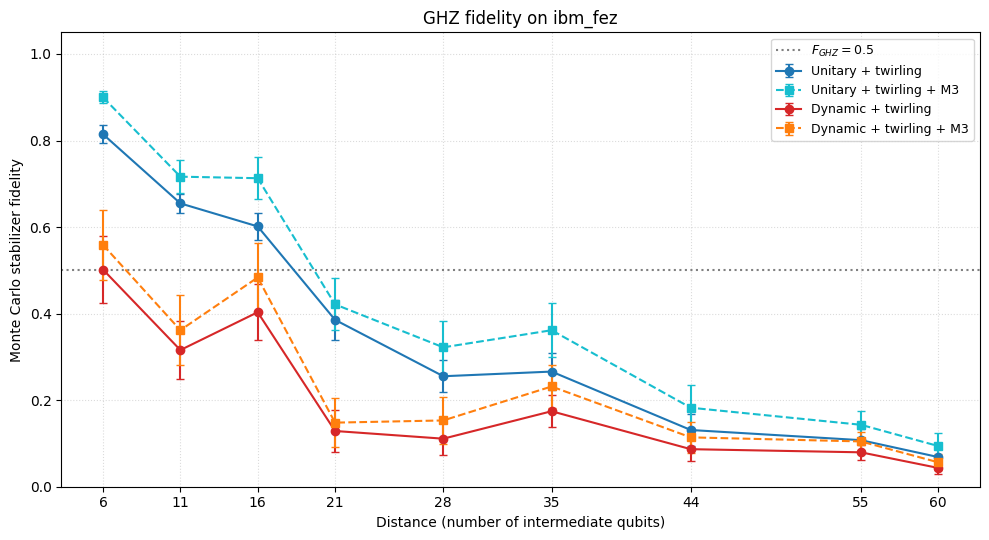

In [18]:
# Keep disabled until the complete sweep is ready to consume QPU time.
SUBMIT_TO_HARDWARE = True
hardware_jobs = {}
m3_hardware = None

if SUBMIT_TO_HARDWARE:
    m3_hardware = mthree.M3Mitigation(hardware_backend)
    m3_hardware.cals_from_system(
        sorted(set(hardware_max_path)),
        method="balanced",
    )

    # One job per distance. Each job contains unitary pubs followed by dynamic pubs.
    with Batch(backend=hardware_backend) as batch:
        hardware_sampler = Sampler(mode=batch)
        for distance in hardware_distances:
            experiment = hardware_experiments[distance]
            combined_circuits = (
                experiment["isa_unitary"] + experiment["isa_dynamic"]
            )
            job = hardware_sampler.run(combined_circuits, shots=hardware_shots)
            hardware_jobs[distance] = job
            print(f"distance={distance:2d}: job_id={job.job_id()}")
else:
    print("ISA circuits are ready. Set SUBMIT_TO_HARDWARE = True to submit.")

# Retrieve completed jobs, calculate raw/M3 fidelities, print, and plot.
hardware_fidelities = {"unitary": {}, "dynamic": {}}

if hardware_jobs:
    for distance in hardware_distances:
        experiment = hardware_experiments[distance]
        block_size = experiment["block_size"]
        result = hardware_jobs[distance].result()
        unitary_result = [result[index] for index in range(block_size)]
        dynamic_result = [
            result[index] for index in range(block_size, 2 * block_size)
        ]

        common_arguments = (
            experiment["stabilizers"],
            hardware_num_twirls,
            experiment["n_qubits"],
            m3_hardware,
        )
        hardware_fidelities["unitary"][distance] = analyze_twirled_result(
            unitary_result, *common_arguments
        )
        hardware_fidelities["dynamic"][distance] = analyze_twirled_result(
            dynamic_result, *common_arguments
        )

    print(
        f"{'d':>3} {'n':>3}  {'Unitary raw':>12}  {'Unitary + M3':>14}  "
        f"{'Dynamic raw':>12}  {'Dynamic + M3':>14}"
    )
    print("-" * 73)
    for distance, n_qubits in zip(hardware_distances, hardware_qubit_counts):
        unitary_result = hardware_fidelities["unitary"][distance]
        dynamic_result = hardware_fidelities["dynamic"][distance]
        print(
            f"{distance:3d} {n_qubits:3d}  "
            f"{unitary_result['raw']:.4f} +/- {unitary_result['raw_sem']:.4f}  "
            f"{unitary_result['m3']:.4f} +/- {unitary_result['m3_sem']:.4f}  "
            f"{dynamic_result['raw']:.4f} +/- {dynamic_result['raw_sem']:.4f}  "
            f"{dynamic_result['m3']:.4f} +/- {dynamic_result['m3_sem']:.4f}"
        )

    fig, ax = plt.subplots(figsize=(10, 5.5))
    hardware_plot_specs = [
        ("unitary", "raw", "raw_sem", "o-", "tab:blue", "Unitary + twirling"),
        ("unitary", "m3", "m3_sem", "s--", "tab:cyan", "Unitary + twirling + M3"),
        ("dynamic", "raw", "raw_sem", "o-", "tab:red", "Dynamic + twirling"),
        ("dynamic", "m3", "m3_sem", "s--", "tab:orange", "Dynamic + twirling + M3"),
    ]

    for variant, value_key, error_key, style, color, label in hardware_plot_specs:
        values = [
            hardware_fidelities[variant][distance][value_key]
            for distance in hardware_distances
        ]
        errors = [
            hardware_fidelities[variant][distance][error_key]
            for distance in hardware_distances
        ]
        ax.errorbar(
            hardware_distances,
            values,
            yerr=errors,
            fmt=style,
            color=color,
            capsize=3,
            label=label,
        )

    ax.axhline(0.5, color="gray", linestyle=":", label="$F_{GHZ}=0.5$")
    ax.set_title("GHZ fidelity on ibm_fez")
    ax.set_xlabel("Distance (number of intermediate qubits)")
    ax.set_ylabel("Monte Carlo stabilizer fidelity")
    ax.set_xticks(hardware_distances)
    ax.set_ylim(0.0, 1.05)
    ax.grid(True, linestyle=":", alpha=0.45)
    ax.legend(fontsize=9)
    fig.tight_layout()
    fig.savefig(
        "figures/ghz_ibm_fez_distance_sweep.png",
        dpi=200,
        bbox_inches="tight",
    )
    plt.show()